In [ ]:
import numpy as np
from sklearn.linear_model import lars_path, lasso_path

def sample(d, n, k, seed=0):
  # d >= k
  shape = (d, n)

  rng = np.random.default_rng(seed=seed)
  X = rng.standard_normal(shape)

  mask = rng.standard_normal(shape)
  m = np.sort(mask, axis=0)[k-1, :, np.newaxis]
  mask = ((mask - m.T) <= 0).astype(int)

  return X * mask

def normalize_columns(X): # normalize columns, avoiding division by 0
    n = np.linalg.norm(X, axis=0)

    return np.divide(X, n, where=(n>0), out=np.zeros_like(X))

def norm_mse(X, Y):

  Xn = normalize_columns(X)
  Yn = normalize_columns(Y)

  return (np.linalg.norm(Xn-Yn, axis=0)**2).mean()

def lasso_lars_oracle(Phi, y, oracle, topk=0):
  # y = sign(Phi @ oracle). oracle should also be normalized here
  _, _, coef_path = lars_path(Phi, y, method='lasso') # coef_path has dimension d x (# of alphas it tried)

  if topk > 0:
    coef_path = hard_threshold(coef_path.T, topk).T

  coef_path_n = normalize_columns(coef_path)
  
  C = ((coef_path_n - oracle[:, np.newaxis])**2).sum(axis=0)

  minx = np.argmin(C)

  if (n := np.linalg.norm(coef_path.T[minx])) > 0:
     y = coef_path.T[minx] / n
  else:
     y = coef_path.T[minx]

  return y  # return best x(alpha)

def lasso_lars_threshold(Phi, y, eps=0.577, topk=0):
  # eps = 1/sqrt(3)
  
  _, _, coef_path = lars_path(Phi, y, method='lasso') # coef_path has dimension d x (# of alphas it tried)

  if topk > 0:
    coef_path = hard_threshold(coef_path.T, topk).T

  rms = np.sqrt(((Phi @ coef_path - y[:, np.newaxis])**2).sum(axis=0) / Phi.shape[0])

  threshold = rms < eps

  threshold = np.array([])

  if np.flatnonzero(threshold).size > 0:
    ix = np.argmax(threshold)
  else:
    ix = np.argmin(rms)

  if (n := np.linalg.norm(coef_path.T[ix])) > 0:
     y = coef_path.T[ix] / n
  else:
     y = coef_path.T[ix]

  return y # return first x(alpha) where the residual |Phi coef_path[:, i] - y| < eps

def hard_threshold(x, k):
  if x.shape[-1] <= k:
    return x.copy()

  abs_x = np.abs(x)
  # partition gives the k-th largest value per row
  threshold = np.partition(abs_x, -k, axis=-1)[..., -k:]
  cutoff = threshold[..., :1]  # shape (..., 1) for broadcasting

  return np.where(abs_x >= cutoff, x, 0.0)

In [ ]:
def l1_prox(x, v):
  return np.sign(x) * np.maximum(np.abs(x) - v, 0)

def renormalized_fpc_(Phi, Phi_pinv, y, Phi_n, init=None, sparse_proj=0, prox=True):

  gamma = 0.999
  xtol = 1e-6
  gtol = 0.2

  d = 2.0 / Phi_n

  if init == None:
    undersampling_ratio = Phi.shape[1] / y.shape[0]
    if (abs(1 - undersampling_ratio) < 0.1): # initialize with the transpose if the matrix is near-square, since the condition number is high in that case
      x = Phi.T @ y
    else:
      x = Phi_pinv @ y # otherwise initialize to Phi^+ y, recommended in the paper

    x /= np.linalg.norm(x)
  elif init == 'lasso':
    x = lasso_lars_threshold(Phi, y)
  l = 0.02
  c = 2

  k = 0
  out_max = 50
  in_max = 100

  js = []

  while(k < out_max):
    j = 0

    while(j < in_max):
      j += 1
      m = 0
      xprev = x.copy()

      # the paper writes Y = diag(y), the matrix with y down its diagonal. then Y x just flips the signs of x according to the entries of y.
      # but since the entries of y are just +1 or -1 we can write Y x as y * x (elementwise), so we can avoid forming the dense Y matrix. then the gradient
      # (Y Phi)^T f(Y Phi x) = Phi^T Y f'(y * (Phi x)) = Phi^T (y * f'(y * (Phi x)))
      # then f' is just the gradient of the one-sided quadratic penalty, so f'(x) = min(x, 0), and we get the expression below

      tmp = y * (Phi @ x) 
      gF = Phi.T @ (y * np.minimum(tmp, 0))

      gF = gF - np.dot(gF, x) * x # subtract radial component 

      h = x - (d) * gF # gradient descent

      z = h
      if prox:
        z = l1_prox(h, d/l)                   # apply the proximal operator

      zn = np.linalg.norm(z) # check if the new solution has norm 0. if so we skip

      if zn == 0:
        break
        
      if sparse_proj > 0:
        abs_z = np.abs(z)
        threshold = np.partition(np.abs(z), -sparse_proj, axis=0)[-sparse_proj]  # value of the k-th largest
        
        z = np.where(abs_z >= threshold, z, 0.0)

      x = z / zn # normalize

      if (np.abs(1 - (x.T @ xprev)) < xtol): # break inner loop when |1 - <x^k, x^{k+1}>| is small
        break

    k += 1
    l *= c
    js.append(j)

  return x

def renormalized_fpc(Phi, Y, init='default', sparse_proj=0, prox=True):

  Phi_n = np.linalg.norm(Phi, ord=2)**2

  Phi_pinv = np.linalg.pinv(Phi)
  Xh = np.zeros((Phi.shape[1], Y.shape[1]))

  for i in range(Y.shape[1]):
    Xh[:, i] = renormalized_fpc_(Phi, Phi_pinv, Y[:, i], Phi_n=Phi_n, init=init, sparse_proj=sparse_proj, prox=prox)

  return Xh

def classical_cs(X, Phi, Y, threshold=0):
  X_n = X / np.linalg.norm(X, axis=0, keepdims=True)
  Xh = np.zeros_like(X)

  for i in range(Y.shape[1]):
    x = lasso_lars_threshold(Phi, Y[:, i], topk=threshold)  
    
    Xh[:, i] = x

  return Xh

def classical_cs_oracle(X, Phi, Y, threshold=0):

  Y = np.sign(Phi @ X)
  X_n = X / np.linalg.norm(X, axis=0, keepdims=True)
  Xh = np.zeros_like(X)

  for i in range(Y.shape[1]):
    x = lasso_lars_oracle(Phi, Y[:, i], X_n[:, i], topk=threshold)

    Xh[:, i] = x

  return Xh

def sparse_sphere_proj(x, k, threshold=1e-3):
  abs_x = np.abs(x)
  threshold = np.partition(np.abs(x), -k, axis=0)[-k]  # value of the k-th largest
  
  x_s = np.where(abs_x >= threshold, x, 0.0)
  
  return (x_s / np.linalg.norm(x_s, ord=2))

def biht_(Phi, y, k, M, max_iters):
  eta = np.sqrt(2*np.pi)

  x = Phi.T @ y

  for _ in range(max_iters):
    x = x + (eta / M) * Phi.T @ ((1 / 2) * (y - np.sign(Phi @ x)))

    x = sparse_sphere_proj(x, k)

  return x

def biht(X, Phi, Y, k):
  M = Phi.shape[0]

  max_iters = 25

  Y = np.sign(Phi @ X)
  Xh = np.zeros_like(X)

  for i in range(Y.shape[1]):
    x = biht_(Phi, Y[:, i], k, M, max_iters)

    Xh[:, i] = x

  return Xh


In [ ]:
import time
import matplotlib.pyplot as plt

def fit_sample( 
  n = 10,
  d = 512,
  k = 16,
  Ms = [50, 100, 200, 500, 1000, 2000, 3000],
  threshold = 0,
  seed=0):

  X = sample(d, n, k)

  mse_rfpc, mse_lars, mse_biht, t_rfpc, t_lars = [], [], [], [], []

  for M in Ms:
    rng = np.random.default_rng(seed)
    Phi = rng.standard_normal((M, d)) #/ np.sqrt(M)

    Y = np.sign(Phi @ X)

    u0 = time.perf_counter()
    Xh1 = classical_cs(X, Phi, Y, threshold=k)
    u = time.perf_counter() - u0

    t0 = time.perf_counter()
    Xh = renormalized_fpc(Phi, Y, init=None, sparse_proj=k)
    t = time.perf_counter() - t0

    u0 = time.perf_counter()
    Xh2 = biht(X, Phi, Y, k)
    u = time.perf_counter() - u0

    print(f"M={M} done")

    mse_rfpc += [10*np.log10(norm_mse(X, Xh))]
    mse_lars += [10*np.log10(norm_mse(X, Xh1))]
    mse_biht += [10*np.log10(norm_mse(X, Xh2))]

    t_rfpc += [t]
    t_lars += [u]
    
  return Xh, Xh1, Xh2, mse_rfpc, mse_lars, mse_biht

Ms = [50, 100, 200, 500, 1000, 2000, 3000]  

k = 16
d = 512
n = 10

threshold = k

Xh, Xh1, Xh2, mse_rfpc, mse_lars, mse_biht = fit_sample(n, d, k, Ms=Ms, threshold=threshold)


M=50 done
M=100 done


KeyboardInterrupt: 

In [7]:
def plot_cs_comparison(m_values, mse_classical, mse_1bit, mse_oracle=None):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(m_values, mse_classical, 'b--', label='lasso lars')
    ax.plot(m_values, mse_biht, 'k-', label='biht')
    ax.plot(m_values, mse_1bit, 'b-', label='rpfc')
    
    ax.set_xlabel('Measurements')
    ax.set_ylabel('MSE (dB)')
    ax.set_title(f'sparsity K={k}')
    ax.legend()
    ax.set_xlim(0, 3000)
    ax.set_ylim(-40, 0)
    ax.axvline(1000, color='k', linestyle='--', linewidth=0.25)
    ax.axvline(2000, color='k', linestyle='--', linewidth=0.25)
    ax.axhline(-10, color='k', linestyle='--', linewidth=0.25)
    ax.axhline(-20, color='k', linestyle='--', linewidth=0.25)
    plt.tight_layout()
    plt.show()

tol = 1e-3

print(f"rpfc avg sparsity: {np.mean(np.sum(np.abs(Xh) > tol, axis=0))}")
print(f"lasso-lars avg sparsity: {np.mean(np.sum(np.abs(Xh1) > tol, axis=0))}")
print(f"biht avg sparsity: {np.mean(np.sum(np.abs(Xh2) > tol, axis=0))}")

plot_cs_comparison(Ms, mse_lars, mse_rfpc, mse_oracle=None)

NameError: name 'Xh' is not defined

k=16, M=50 done
k=16, M=100 done
k=16, M=200 done
k=16, M=500 done
k=16, M=1000 done
k=16, M=2000 done
k=16, M=3000 done
k=32, M=50 done
k=32, M=100 done
k=32, M=200 done
k=32, M=500 done
k=32, M=1000 done
k=32, M=2000 done
k=32, M=3000 done


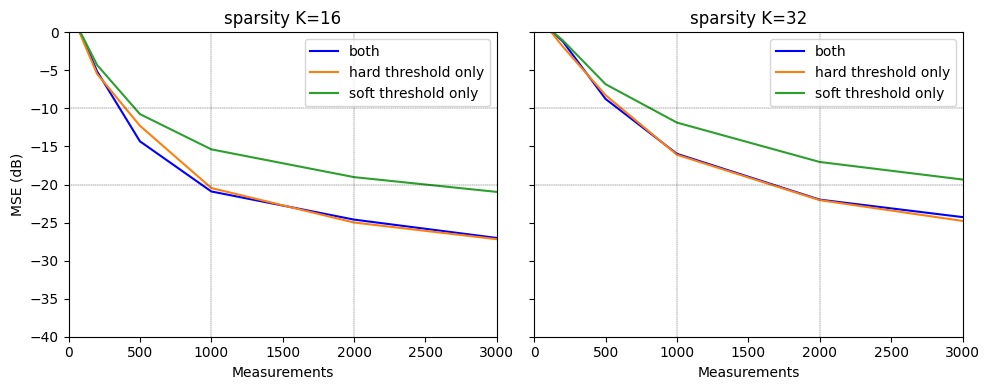

In [8]:
def fit_rfpc_variants(
  n = 10,
  d = 512,
  k = 16,
  Ms = [50, 100, 200, 500, 1000, 2000, 3000],
  seed=0):

  X = sample(d, n, k)
  mse_both, mse_hard, mse_soft = [], [], []

  for M in Ms:
    rng = np.random.default_rng(seed)
    Phi = rng.standard_normal((M, d))
    Y = np.sign(Phi @ X)

    Xh_both = renormalized_fpc(Phi, Y, init=None, sparse_proj=k, prox=True)
    Xh_hard = renormalized_fpc(Phi, Y, init=None, sparse_proj=k, prox=False)
    Xh_soft = renormalized_fpc(Phi, Y, init=None, sparse_proj=0, prox=True)

    print(f"k={k}, M={M} done")

    mse_both += [10*np.log10(norm_mse(X, Xh_both))]
    mse_hard += [10*np.log10(norm_mse(X, Xh_hard))]
    mse_soft += [10*np.log10(norm_mse(X, Xh_soft))]

  return mse_both, mse_hard, mse_soft


def plot_rfpc_variant_comparison(m_values, mse_both, mse_hard, mse_soft, k, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    ax.plot(m_values, mse_both, 'b-', label='both')
    ax.plot(m_values, mse_hard, color='tab:orange', label='hard threshold only')
    ax.plot(m_values, mse_soft, color='tab:green', label='soft threshold only')

    ax.set_xlabel('Measurements')
    ax.set_ylabel('MSE (dB)')
    ax.set_title(f'sparsity K={k}')
    ax.legend()
    ax.set_xlim(0, 3000)
    ax.set_ylim(-40, 0)
    ax.axvline(1000, color='k', linestyle='--', linewidth=0.25)
    ax.axvline(2000, color='k', linestyle='--', linewidth=0.25)
    ax.axhline(-10, color='k', linestyle='--', linewidth=0.25)
    ax.axhline(-20, color='k', linestyle='--', linewidth=0.25)

    return ax


fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, k_value in zip(axes, [16, 32]):
  mse_both, mse_hard, mse_soft = fit_rfpc_variants(n=n, d=d, k=k_value, Ms=Ms)
  plot_rfpc_variant_comparison(Ms, mse_both, mse_hard, mse_soft, k_value, ax=ax)

axes[1].set_ylabel('')
plt.tight_layout()
plt.show()